In [1]:
import icarusplot
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os

@@ Importing mplstyle from /Users/jskim/lib/icarusplot//icarus_style.mplstyle


In [2]:
FluxFileName = '2024-04-02_ICARUS_g3Chase_PPFX_FHC_flux.root'

HistName_numu = 'hflux_fhc_numu'
HistName_numubar = 'hflux_fhc_numubar'


In [3]:
with uproot.open(FluxFileName) as f:

    h_numu = f[HistName_numu]
    h_numubar = f[HistName_numubar]

In [4]:
Binning_numu = h_numu.to_numpy()[1]
BinWidth_numu = np.diff(Binning_numu)
FluxValue_numu = h_numu.to_numpy()[0]
Area_numu = np.sum(FluxValue_numu)

Binning_numubar = h_numubar.to_numpy()[1]
BinWidth_numubar = np.diff(Binning_numubar)
FluxValue_numubar = h_numubar.to_numpy()[0]
Area_numubar = np.sum(FluxValue_numubar)

In [5]:
FluxCut = 0

LowArea_numu = 0.
for ibin in range(len(Binning_numu)-1):
    x_l = Binning_numu[ibin]
    x_r = Binning_numu[ibin+1]
    x_c = (x_l+x_r)/2.
    if x_c<FluxCut:
       LowArea_numu +=  FluxValue_numu[ibin]

LowArea_numubar = 0.
for ibin in range(len(Binning_numubar)-1):
    x_l = Binning_numubar[ibin]
    x_r = Binning_numubar[ibin+1]
    x_c = (x_l+x_r)/2.
    if x_c<FluxCut:
       LowArea_numubar +=  FluxValue_numubar[ibin]

Integral_numu = Area_numu - LowArea_numu
Integral_numubar = Area_numubar - LowArea_numubar
Integral_Sum = Integral_numu+Integral_numubar

POT = 8.0746178e+20

print('numu', '%e'%(Integral_numu * POT * 1E-4))
print('numubar', '%e'%(Integral_numubar * POT * 1E-4))

print('numu/(numu_numubar)', Integral_numu/(Integral_numu+Integral_numubar))

print('Sum', '%e'%(Integral_Sum * POT * 1E-4))


numu 3.970372e+11
numubar 2.251263e+11
numu/(numu_numubar) 0.6381557471268917
Sum 6.221635e+11


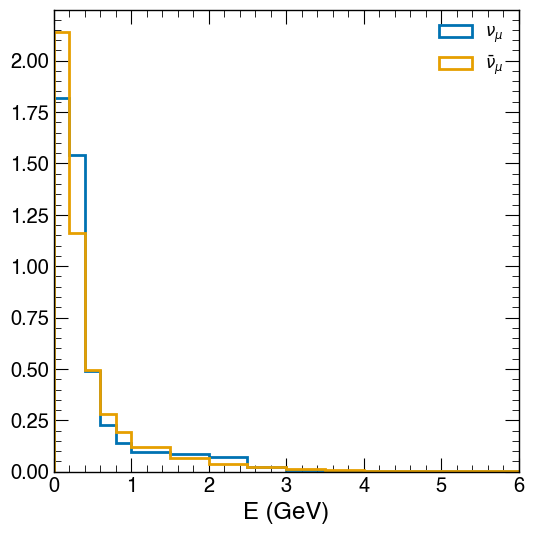

In [7]:
fig, ax = plt.subplots(figsize=(6,6))

ax.hist(
    Binning_numu[:-1], 
    bins=Binning_numu,
    weights=FluxValue_numu/BinWidth_numu/Area_numu,
    histtype='step',
    label=r'$\nu_{\mu}$',
)

ax.hist(
    Binning_numubar[:-1], 
    bins=Binning_numubar,
    weights=FluxValue_numubar/BinWidth_numubar/Area_numubar,
    histtype='step',
    label=r'$\bar{\nu}_{\mu}$',
)

ax.set_xlabel('E (GeV)')
ax.set_xlim(0.,6.0)

ax.legend()